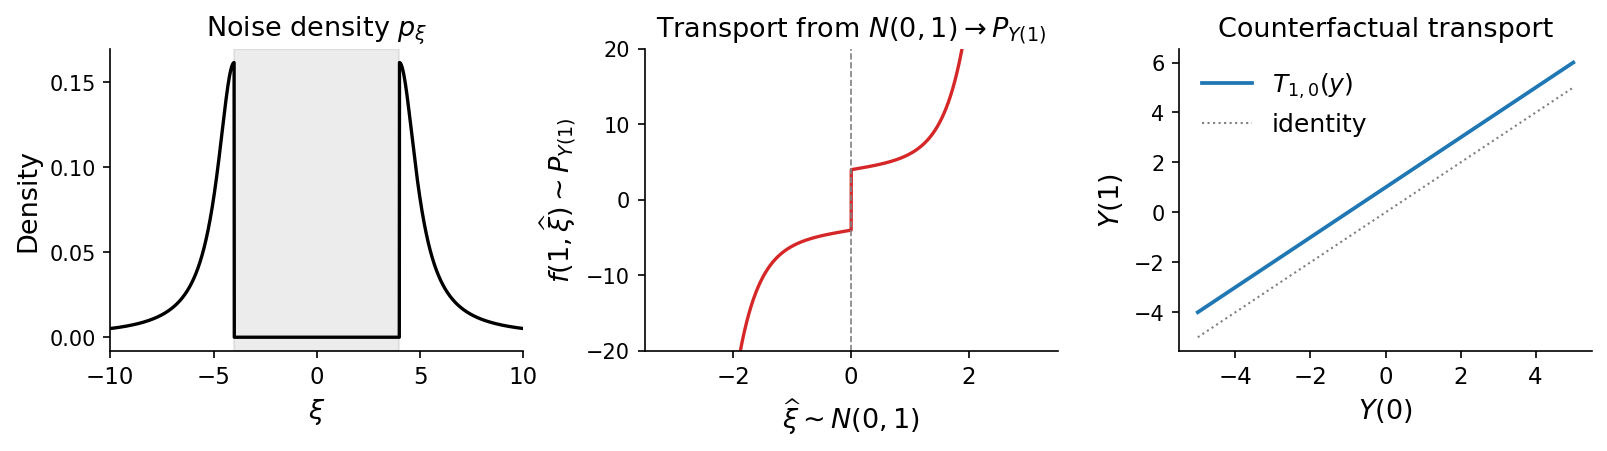

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, cauchy
from scipy.interpolate import interp1d

# -----------------------------
# Global plotting style (JMLR-ish)
# -----------------------------
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "legend.fontsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
})

# -----------------------------
# Construct a "nasty" noise distribution
# -----------------------------
# 1) Extend x-range so tails are represented (critical)
x = np.linspace(-1000, 1000, 200_000)

# 2) Make oscillations create near-troughs (still nonnegative)
a = 4
eps = 1   # smaller => sharper troughs
omega = 0
osc1 = eps + (np.sin(omega*(x - a))**2)
osc2 = eps + (np.sin(omega*(x + a))**2)

density = (
    0.5 * cauchy.pdf(x - a) * osc1 +
    0.5 * cauchy.pdf(x + a) * osc2
)

# hard gap
density[(x > -a) & (x < a)] = 0.0
#density /= np.trapz(density, x)

# 3) Use a wider u-range to see blow-up
dx = x[1] - x[0]
cdf = np.cumsum(density) * dx
cdf /= cdf[-1]   # normalize *here*, not before
inv_cdf = interp1d(
    cdf,
    x,
    kind="linear",
    bounds_error=False,
    fill_value=(x[0], x[-1])   # THIS is the saturation
)
u = np.linspace(-10, 10, 100000)
transport_noise = inv_cdf(norm.cdf(u))


# -----------------------------
# Counterfactual transport
# -----------------------------
y = np.linspace(-5, 5, 500)
beta = 1.0
T_10 = y + beta

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

# (a) Noise density
axes[0].plot(x, density, color="black", lw=1.6)
axes[0].axvspan(-a, a, color="gray", alpha=0.15)
axes[0].set_title("Noise density $p_\\xi$")
axes[0].set_xlabel("$\\xi$")
axes[0].set_ylabel("Density")
axes[0].set_xlim(-10, 10)

# (b) Noise transport
axes[1].plot(u, transport_noise, color="tab:red", lw=1.6)
axes[1].axvline(0, color="gray", lw=0.8, ls="--")
axes[1].set_title(r"Transport from $N(0,1) \to P_{Y(1)}$")
axes[1].set_xlabel("$\\widehat{\\xi}\\sim N(0,1)$")
axes[1].set_ylabel("$f(1,\\widehat{\\xi}) \sim P_{Y(1)}$")
axes[1].set_xlim(-3.5, 3.5)
axes[1].set_ylim(-20,20)

# (c) Counterfactual transport
axes[2].plot(y, T_10, color="tab:blue", lw=1.8, label="$T_{1,0}(y)$")
axes[2].plot(y, y, color="gray", lw=1.0, ls=":", label="identity")
axes[2].set_title("Counterfactual transport")
axes[2].set_xlabel("$Y(0)$")
axes[2].set_ylabel("$Y(1)$")
axes[2].legend(frameon=False)

plt.tight_layout(w_pad=0)
plt.savefig("illustrative_noise_pathology.pdf", bbox_inches = "tight")
plt.show()